Task 2: Decision Trees

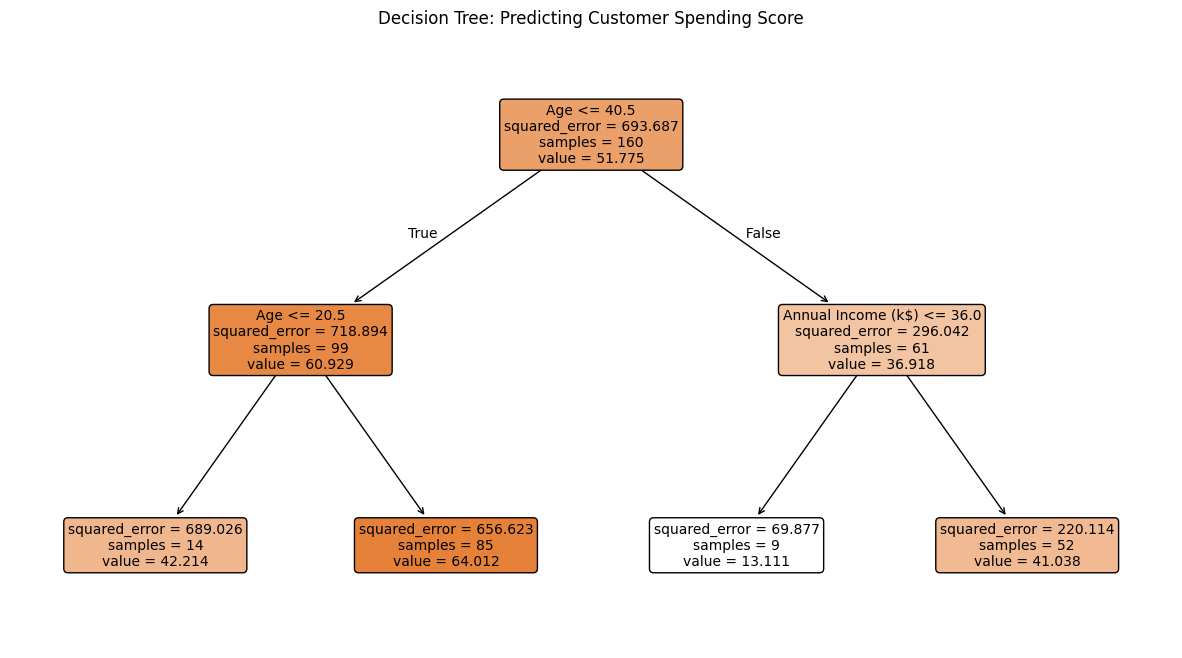

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1. Loading the data of mall customers
mall_data_analysis = pd.read_csv('Mall_Customers.csv')

# Step 2. Preprocessing
# Convert Gender to numbers and drop CustomerID
le = LabelEncoder()
mall_data_analysis['Gender'] = le.fit_transform(mall_data_analysis['Gender'])
X_dt = mall_data_analysis[['Gender', 'Age', 'Annual Income (k$)']]
y_dt = mall_data_analysis['Spending Score (1-100)']

# Step 3. Splitting the data
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

# Step 4. Training for Decision Tree
dt_model = DecisionTreeRegressor(max_depth=2, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

# 5. Visualizing the Tree
plt.figure(figsize=(15,8))
plot_tree(dt_model, feature_names=X_dt.columns, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree: Predicting Customer Spending Score")
plt.show()

Task 3: K-Means Clustering

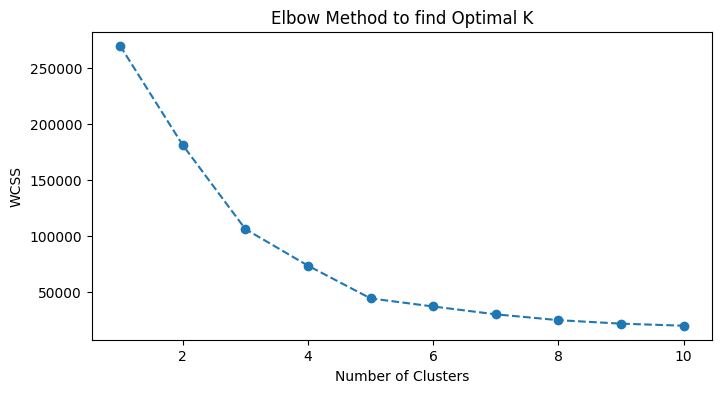

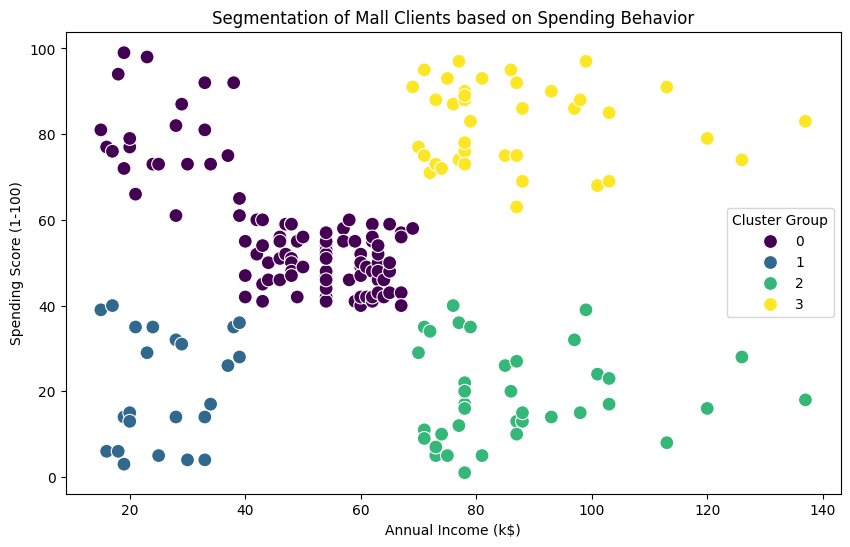

In [ ]:
from sklearn.cluster import KMeans
import seaborn as sns

# Step 1. Selecting features for clustering (Income and Spending Score)
X_clustering = df_customers[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 2. Using the Elbow Method
# This helps us find the best number of groups
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_init=10, n_clusters=i, random_state=42)
    kmeans.fit(X_clustering)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Step 3. Running K-Means with K=5 (The "Elbow" point)
kmeans = KMeans(n_init=10, n_clusters=4, random_state=42)
df_customers['Cluster'] = kmeans.fit_predict(X_clustering)

# Step 4. Visualizing the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_customers, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='viridis', s=100)
plt.title("Segmentation of Mall Clients based on Spending Behavior")
plt.legend(title='Cluster Group')
plt.show()